In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras


In [ ]:
# Generate a 2D non-linear dataset
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (good practice for neural nets)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (800, 2)
y_train shape: (800,)


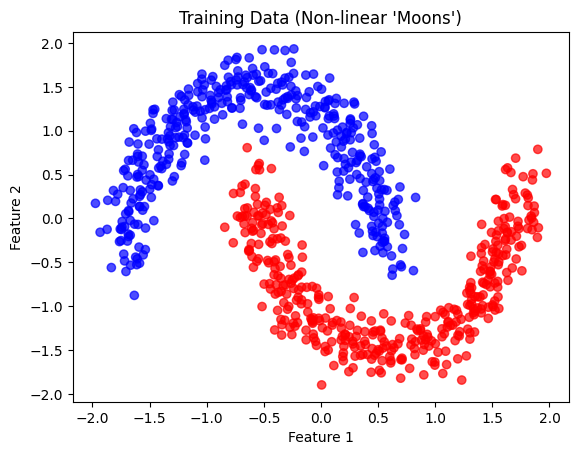

In [50]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr", alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training Data (Non-linear 'Moons')")
plt.show()


In [51]:
model = keras.Sequential([
    keras.layers.Dense(16, activation="relu", input_shape=(2,)),
    keras.layers.Dense(8, activation="relu", input_shape=(2,)),
    keras.layers.Dense(1, activation="sigmoid")
])

model.summary()


c:\Users\abdul\Desktop\coconut-disease-system\backend\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [52]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


In [53]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1  # set to 1 if you want to see progress
)

print("Final training accuracy:", history.history["accuracy"][-1])
print("Final validation accuracy:", history.history["val_accuracy"][-1])


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - accuracy: 0.5537 - loss: 0.6480 - val_accuracy: 0.6650 - val_loss: 0.6210
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.7437 - loss: 0.5956 - val_accuracy: 0.8050 - val_loss: 0.5812
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8313 - loss: 0.5584 - val_accuracy: 0.8150 - val_loss: 0.5451
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8462 - loss: 0.5219 - val_accuracy: 0.8300 - val_loss: 0.5106
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8512 - loss: 0.4807 - val_accuracy: 0.8300 - val_loss: 0.4612
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8512 - loss: 0.4207 - val_accuracy: 0.8300 - val_loss: 0.3986
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8550 - loss: 0.3571 - val_accuracy: 0.8400 - val_loss: 0.3537
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8612 - loss: 0.3188 - val_accuracy: 0.8450 - 

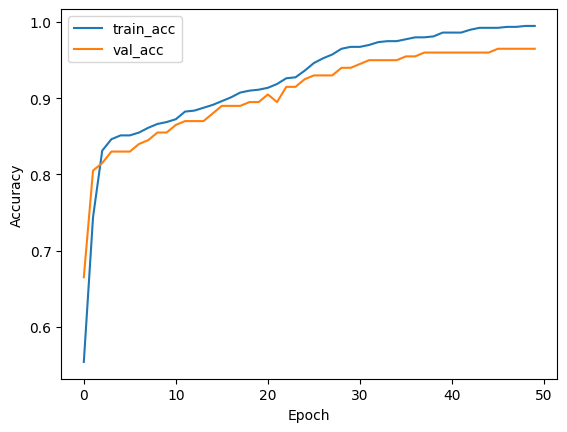

In [54]:
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [55]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)


Test accuracy: 0.9649999737739563


In [56]:
linear_model = keras.Sequential([
    keras.layers.Dense(1, activation="sigmoid", input_shape=(2,))
])

linear_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

linear_history = linear_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)

lin_test_loss, lin_test_acc = linear_model.evaluate(X_test, y_test, verbose=0)
print("Linear model test accuracy:", lin_test_acc)
print("NN with hidden layer test accuracy:", test_acc)


Linear model test accuracy: 0.8299999833106995
NN with hidden layer test accuracy: 0.9649999737739563


In [57]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y, title):
    # Define grid range
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Create a grid of points
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Get model predictions on the grid
    Z = model.predict(grid)
    # Convert probabilities to class labels (0 or 1)
    Z = (Z > 0.5).astype(int)
    Z = Z.reshape(xx.shape)

    # Plot contour and training points
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k", s=20)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")


2813/2813 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step


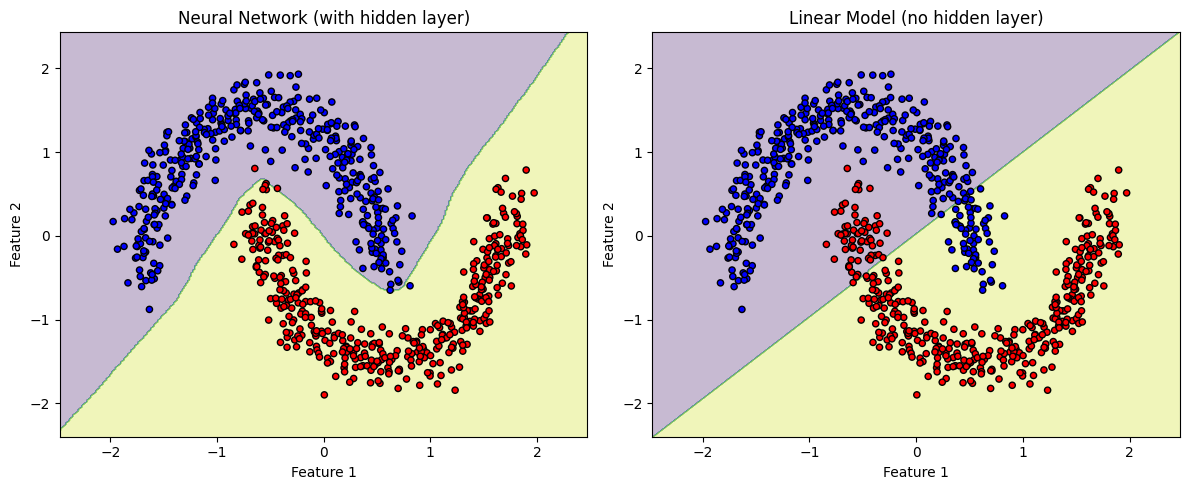

In [58]:
plt.figure(figsize=(12, 5))

# Neural network with hidden layer
plt.subplot(1, 2, 1)
plot_decision_boundary(model, X_train, y_train, "Neural Network (with hidden layer)")

# Linear model (no hidden layer)
plt.subplot(1, 2, 2)
plot_decision_boundary(linear_model, X_train, y_train, "Linear Model (no hidden layer)")

plt.tight_layout()
plt.show()
